<a href="https://colab.research.google.com/github/Dnntello/Prodigy_ML_02/blob/main/K_means_clustering_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# #lets load our data set
# import zipfile

# zip_path = "/content/drive/MyDrive/k-means-clustering-algorithm/archive (1).zip"
# extract_path = "/content/drive/MyDrive/k-means-clustering-algorithm"

# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#   zip_ref.extractall(extract_path)




In [ ]:
from IPython.utils.py3compat import platform
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


customers = pd.read_csv("drive/MyDrive/k-means-clustering-algorithm/Mall_Customers.csv")

customers.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
len(customers)

200

In [ ]:
customers.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [ ]:
X = customers[['Annual Income (k$)', 'Spending Score (1-100)']]

Scale features

In [ ]:
def scale_features(X):
  scaler = StandardScaler()
  X_scaled = scaler.fit_transform(X)
  return X_scaled

X_scaled = scale_features(X)

In [ ]:
#elbow method
#within cluster sum of squares (WCSS)
def elbow_method(X):
  wcss = []

  for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state=42)
    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

  return wcss

wcss = elbow_method(X_scaled)
wcss

[399.99999999999994,
 273.66888662642003,
 157.70400815035939,
 109.22822707921345,
 65.56840815571681,
 60.132874871934206,
 49.668244837367965,
 37.31912287833882,
 32.495081199100916,
 30.05932269404222]

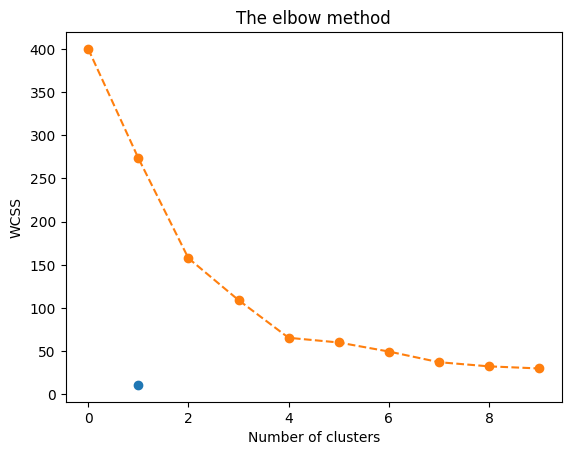

In [ ]:
#plot elbow curve
def plot_elbow_curve(wcss):
  plt.plot(1,11, wcss, marker='o', linestyle='--')
  plt.title('The elbow method')
  plt.xlabel('Number of clusters')
  plt.ylabel('WCSS')

  plt.show()

plot_elbow_curve(wcss)


In [ ]:
#Train k-means model
def train_kmeans(X_scaled, n_clusters, customers):
  kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)

  customers['Cluster'] = kmeans.fit_predict(X_scaled)
  return customers, kmeans

def visualize_clusters(customers):
  plt.figure(figsize=(8,6))

  plt.scatter(
      customers['Annual Income (k$)'],
      customers['Spending Score (1-100)'],
      c = customers['Cluster'],
      cmap='rainbow'
  )
  plt.xlabel("Annual Income (k$)")
  plt.ylabel("Spending Score (1-100)")
  plt.title("Customer segments")

  plt.show()

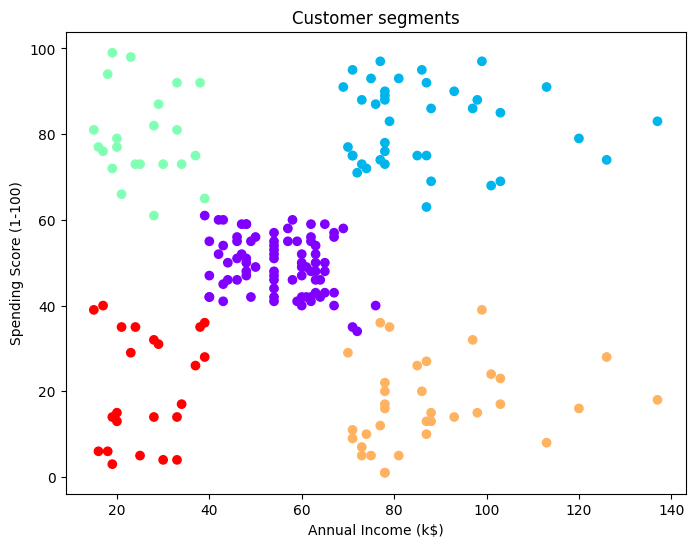

In [ ]:
customers, kmeans = train_kmeans(X_scaled, 5, customers)
visualize_clusters(customers)

The graph above typically represents 4 groups listed below
* Low income-low spending
* Low income-high spending
* High income-low spending
* High income-high spending

In [ ]:
# #lets include age and encoded gender
customers['Gender'] = customers['Gender'].map({
    'Female': 0,
    'Male': 1
})

X = customers[['Annual Income (k$)', 'Spending Score (1-100)', 'Age']]
customers

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,1,19,15,39,4
1,2,1,21,15,81,2
2,3,0,20,16,6,4
3,4,0,23,16,77,2
4,5,0,31,17,40,4
...,...,...,...,...,...,...
195,196,0,35,120,79,1
196,197,0,45,126,28,3
197,198,1,32,126,74,1
198,199,1,32,137,18,3


In [ ]:
#scaling
X_scaled = scale_features(X)

In [ ]:
#rerunning elbow method

wcss = elbow_method(X_scaled)
wcss

[600.0,
 389.38618895643714,
 295.4562449213557,
 205.22514747675913,
 169.89149793438568,
 134.35277477401493,
 121.38935022502866,
 113.72723000071333,
 102.13623844329251,
 92.55027231838784]

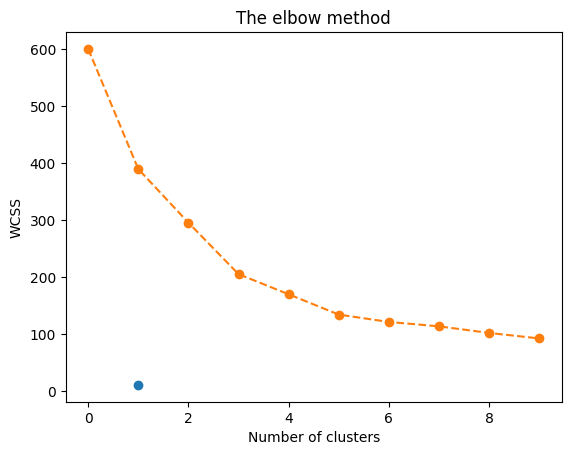

In [ ]:
#plot elbow curve
plot_elbow_curve(wcss)

It doesnt form an elbow pattern now that we've added gender and

age to our data but we can still see that improvements become smaller after 5

In [ ]:
from sklearn.metrics import silhouette_score

def sil_score(X_scaled):
  for k in range(2, 11):
    kmeans = KMeans(n_clusters = k, init = 'k-means++', random_state=42)
    kmeans.fit(X_scaled)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k}, silhouette score={score}")

sil_score(X_scaled)

K=2, silhouette score=0.33547192894004574
K=3, silhouette score=0.3579234303882264
K=4, silhouette score=0.4039582785148566
K=5, silhouette score=0.40846873777345605
K=6, silhouette score=0.4310652621660301
K=7, silhouette score=0.410091114520974
K=8, silhouette score=0.36736631653222945
K=9, silhouette score=0.37442148555078425
K=10, silhouette score=0.36186970479722974


i'm deciding to do clustering without gender because i dont think this feature is effective

for this problem

In [ ]:
X = customers[['Annual Income (k$)', 'Spending Score (1-100)', 'Age']]

X_scaled = scale_features(X)

In [ ]:
wcss = elbow_method(X_scaled)

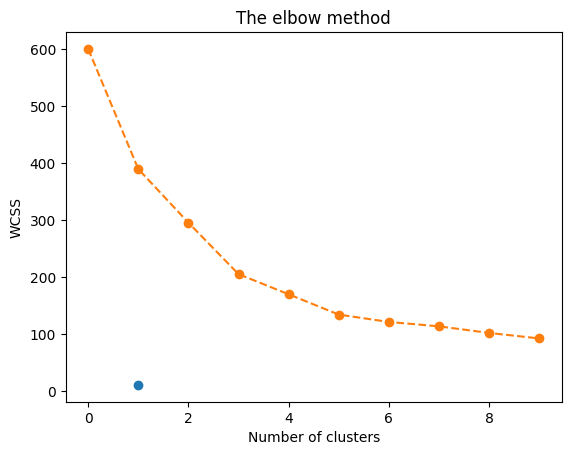

In [ ]:
plot_elbow_curve(wcss)

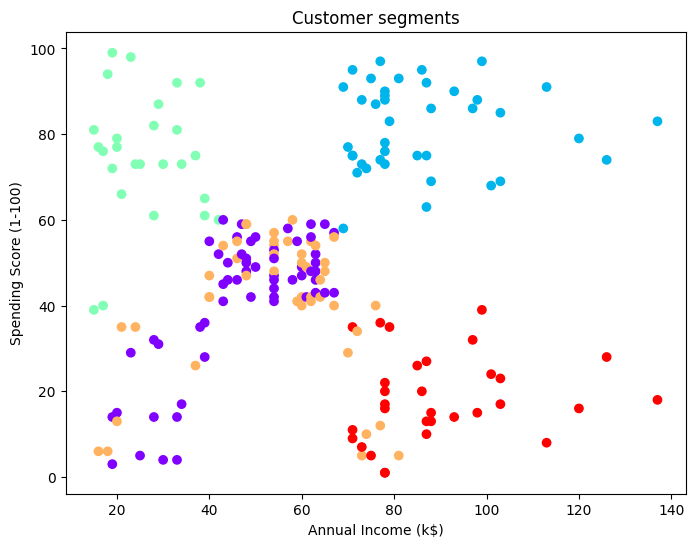

In [ ]:
#Train k-means model
customers, kmeans = train_kmeans(X_scaled, 5, customers)
visualize_clusters(customers)


Hmm, theres an ovelap noticed at the bottom left, let me try k = 4

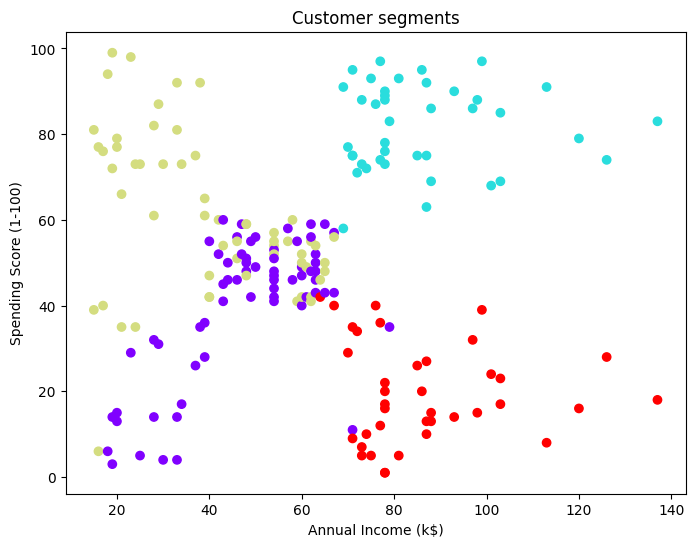

In [ ]:
customers, kmeans = train_kmeans(X_scaled, 4, customers)
visualize_clusters(customers)

Still a major overlap, at this point, im going to

remove both age and gender from X because these scale_features

cause overlapping and takes away simplicity. This takes me back to my first iteration


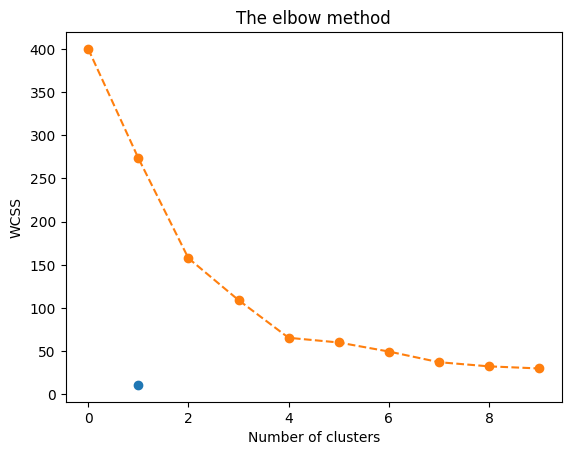

In [ ]:
#going with two best combinations
X = customers[['Annual Income (k$)', 'Spending Score (1-100)']]

X_scaled = scale_features(X)

wcss = elbow_method(X_scaled)

plot_elbow_curve(wcss)

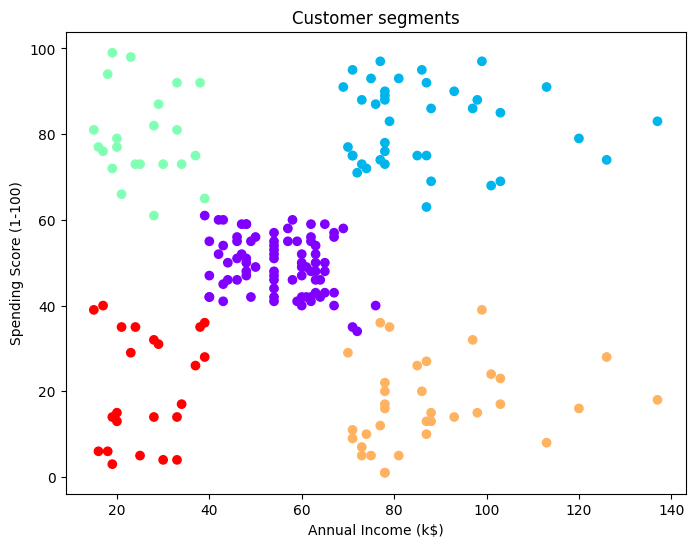

In [ ]:
# lets use k=5
customers, kmeans = train_kmeans(X_scaled, 5, customers)
visualize_clusters(customers)

In [ ]:
# Lets check our silhouette score
sil_score(X_scaled)

K=2, silhouette score=0.3973270007887498
K=3, silhouette score=0.46658474419000145
K=4, silhouette score=0.49434988482196784
K=5, silhouette score=0.5546571631111091
K=6, silhouette score=0.5138257534676561
K=7, silhouette score=0.50200146805547
K=8, silhouette score=0.4550112502601921
K=9, silhouette score=0.4566624374485964
K=10, silhouette score=0.44475993501732874


Demographic variables like age and gender did not improve segmentation quality, while behavioral/economic variables produced clearer customer groups.

The 5 groups often correspond to:

1. High income - high spending
2. High income - low spending
3. Low income - low spending
4. Low income - high spending
5. Average income - average spending

In [ ]:
#centriods
centriods = pd.DataFrame(kmeans.cluster_centers_,
                         columns = ['Annual Income', 'Spending Score'])
centriods


,Annual Income,Spending Score
0,-0.200913,-0.026456
1,0.991583,1.239503
2,-1.329545,1.132178
3,1.055003,-1.284439
4,-1.307519,-1.136965


In [ ]:
customers.groupby('Cluster').mean(numeric_only=True)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,,
0,86.320988,0.407407,42.716049,55.296296,49.518519
1,162.000000,0.461538,32.692308,86.538462,82.128205
2,23.090909,0.409091,25.272727,25.727273,79.363636
3,164.371429,0.542857,41.114286,88.200000,17.114286
4,23.000000,0.391304,45.217391,26.304348,20.913043


In [ ]:
#to see cluster sizes
customers['Cluster'].value_counts()

,count
Cluster,
0,81
1,39
3,35
4,23
2,22


In [ ]:
for i in range(len(customers)):
  if customers.Cluster[i] == 0:
    customers.Cluster[i] = 'Average Customers'
  elif customers.Cluster[i] == 1:
    customers.Cluster[i] = 'Premuim customers'
  elif customers.Cluster[i] == 2:
    customers.Cluster[i] = 'Luxury shoppers'
  elif customers.Cluster[i] == 3:
    customers.Cluster[i] = 'Careful spenders'
  elif customers.Cluster[i] == 4:
    customers.Cluster[i] = 'Budget customers'

customers.head()


/tmp/ipykernel_17815/1005074283.py:11: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  customers.Cluster[i] = 'Budget customers'
/tmp/ipykernel_17815/1005074283.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice f

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,1,19,15,39,Budget customers
1,2,1,21,15,81,Luxury shoppers
2,3,0,20,16,6,Budget customers
3,4,0,23,16,77,Luxury shoppers
4,5,0,31,17,40,Budget customers


In [320]:
#to see cluster sizes
customers['Cluster'].value_counts()

,count
Cluster,
Average Customers,81
Premuim customers,39
Careful spenders,35
Budget customers,23
Luxury shoppers,22
